# Prompt patterns

Try seven prompt patterns in your coding assistant. Compare the answers and decide what helped. Each example includes a prompt to paste and a recorded response to inspect.

## Learn | Create | Grow

### Learn
Compare persona, examples, reasoning effort, requested output formats, and supplied facts.

### Create
Add requirements to a draft, generate and test an instruction, then apply the patterns to your own project.

### Grow
Turn useful prompts into templates and test them across representative inputs.

**Estimated time:** 30 minutes

## Setup

Open Codex, Claude Code, VS Code Copilot, or another interactive coding assistant alongside this guide. Follow [Agent setup and controls](https://github.com/AI-Aspire/Aspire_Titanium_Engineer/blob/eli/interactive-prompt-patterns/docs/CODING_AGENTS.md). Keep the same model and effort setting except when testing reasoning effort.

Start a new conversation before each independent comparison. Stay in the same conversation for the self-refine draft and revision. Paste each quoted prompt as one message.

### What stays in context

A new conversation clears the chat history, but repository instructions, memory, or editor context may remain. The role you paste is a user instruction; the application manages its own system instructions.

If your assistant reads files or uses tools, it has extra information. Keep that in mind when comparing it with an answer based only on the pasted text.

<details>
<summary>About the recorded responses</summary>

These are actual model-only reference conversations using gpt-5.6-luna through the OpenAI Responses API, not recordings of a coding-agent interface. Effort was low except for the high-effort comparison. No tools or repository instructions were supplied. The self-refine revision includes the actual preceding draft in its history.

Your assistant may use different models, instructions, and context. [Recording data](data/recorded_responses.json) preserves exact messages, responses, settings, usage, and request IDs.

</details>

# Learn

## Task 1 of 7 — Persona

Compare the same support question with and without a role and response constraints.

### A: baseline

> A colleague says the VPN connects but they cannot reach the staging database. What should they do first?

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> First, verify that the VPN is providing a route to the staging network—not just showing “connected.”
>
> Have them:
>
> 1. Confirm they’re using the correct staging VPN/profile.
> 2. Resolve the database hostname (`nslookup`/`dig`).
> 3. Test the database port, typically with `nc -vz <db-host> <port>` or the equivalent—not just ping.
>
> If DNS or the port check fails, it’s likely a VPN route, firewall/security-group, or IP allowlist issue rather than a database-credential problem.

</details>

### B: persona and constraints

> You are a terse lead engineer. Answer in three sentences or fewer. Give the first diagnostic step and explain why.
>
> A colleague says the VPN connects but they cannot reach the staging database. What should they do first?

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> First, verify basic network reachability to the database host and port from the VPN client (for example, `nc -vz <db-host> <db-port>`). This distinguishes a VPN/routing/firewall problem from database authentication or configuration issues before deeper investigation.

</details>

Takeaway: The persona version is shorter and focuses on reachability; the baseline lists several checks. Role and length constraints changed together, so this does not isolate the effect of persona.

Ask the room: Which answer gives a clearer first action, and what would you verify before following it?

## Task 2 of 7 — Few-shot

Examples teach a local convention. This example support desk handles reservations but routes equipment faults elsewhere. Its scope is different from Deskmate’s.

### A: no examples

> Classify the request for this example support desk as IN_SCOPE or OUT_OF_SCOPE. Give the label and one sentence explaining it.
>
> Request: Can you reserve a meeting room for Thursday?

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> OUT_OF_SCOPE — Reserving a meeting room is a facilities or administrative request, not a technical support issue.

</details>

### B: a local convention

> Classify the request for this example support desk as IN_SCOPE or OUT_OF_SCOPE. Give the label and one sentence explaining it.
>
> Example: Can you book a desk for my office visit?
> Label: IN_SCOPE. This desk handles workspace reservations.
>
> Example: My monitor will not turn on.
> Label: OUT_OF_SCOPE. This desk routes equipment faults to a separate hardware team.
>
> Request: Can you reserve a meeting room for Thursday?

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> Label: IN_SCOPE. This desk handles meeting room reservations.

</details>

Takeaway: The baseline assumes a conventional support scope and says OUT_OF_SCOPE. With examples, it follows the local reservation rule and says IN_SCOPE.

Ask the room: Which fact did the examples supply that the original request left unspecified?

### ❓ Question
Write down one convention in your charter that the model could not guess from language alone. That is your first few-shot example.

Answer:

## Task 3 of 7 — Reasoning effort

Keep the model and prompt identical while changing the actual reasoning-effort setting. Asking the model to “think carefully” is a different experiment.

Use your assistant’s [effort controls](https://github.com/AI-Aspire/Aspire_Titanium_Engineer/blob/eli/interactive-prompt-patterns/docs/CODING_AGENTS.md#reasoning-effort). If unavailable, choose a supported model for both trials or inspect the recorded pair. Do not compare different models and attribute the result only to effort.

The prompt follows [Simon Willison’s SVG comparison](https://simonwillison.net/2026/Jul/9/gpt-5-6/).

### A: low effort

Start a new conversation with the same model. Select low effort (or the corresponding available level), confirm the setting, start a timer, and send:

> Generate an SVG of a pelican riding a bicycle.

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve verbatim SVG source. -->
<details>
<summary>Recorded SVG source · low effort · gpt-5.6-luna</summary>

```svg
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 700 520" width="700" height="520">
  <title>A pelican riding a bicycle</title>
  <desc>A cheerful pelican pedals a red bicycle.</desc>

  <rect width="700" height="520" fill="#dff4ff"/>
  <path d="M0 410 Q170 385 340 410 T700 405 V520 H0Z" fill="#b9df9b"/>
  <path d="M0 438 Q180 420 350 438 T700 430" fill="none" stroke="#8fc477" stroke-width="5"/>

  <!-- Bicycle -->
  <g fill="none" stroke="#273746" stroke-width="8" stroke-linecap="round" stroke-linejoin="round">
    <circle cx="190" cy="390" r="72" fill="#f8fbff"/>
    <circle cx="535" cy="390" r="72" fill="#f8fbff"/>

    <path d="M190 390 L285 275 L365 390 L190 390 L535 390 L365 390 L430 285 L535 390"/>
    <path d="M285 275 L270 245"/>
    <path d="M255 245 H292"/>
    <path d="M430 285 L458 238"/>
    <path d="M448 238 H485"/>
    <path d="M458 238 Q475 220 493 230"/>
    <circle cx="365" cy="390" r="13" fill="#f39c35"/>
    <path d="M365 390 L330 350 M365 390 L403 425"/>
    <path d="M330 350 H310 M403 425 H423"/>
  </g>

  <!-- Bicycle frame accents -->
  <path d="M190 390 L285 275 L365 390" fill="none" stroke="#e85d4a" stroke-width="10" stroke-linecap="round"/>
  <path d="M365 390 L535 390" fill="none" stroke="#e85d4a" stroke-width="10"/>

  <!-- Pelican body -->
  <g stroke="#263746" stroke-width="5" stroke-linejoin="round">
    <path d="M302 245
             Q285 215 299 173
             Q315 128 365 122
             Q421 116 449 160
             Q469 192 448 235
             Q431 270 384 279
             Q331 287 302 245Z"
          fill="#f4f6f2"/>

    <!-- Wing -->
    <path d="M335 190 Q382 170 426 201 Q405 242 359 249 Q329 246 317 225Z"
          fill="#d7e1df"/>
    <path d="M347 209 Q380 222 409 214" fill="none" stroke="#a7b9b8" stroke-width="4"/>

    <!-- Neck -->
    <path d="M367 153 Q349 117 368 88 Q386 62 418 75
             Q441 85 441 112 Q441 140 420 160Z"
          fill="#f4f6f2"/>

    <!-- Head -->
    <ellipse cx="413" cy="78" rx="43" ry="39" fill="#f4f6f2"/>
    <circle cx="430" cy="68" r="5" fill="#263746" stroke="none"/>

    <!-- Pelican beak/pouch -->
    <path d="M390 89 Q345 82 292 98 Q278 103 290 114
             Q337 146 389 123 Q414 112 420 95Z"
          fill="#f2a33b"/>
    <path d="M292 98 Q326 105 388 108" fill="none" stroke="#c87827" stroke-width="3"/>
    <path d="M290 114 Q331 130 379 119" fill="none" stroke="#d37f2d" stroke-width="3"/>

    <!-- Tail -->
    <path d="M306 228 Q270 225 244 245 Q274 254 315 251Z" fill="#d7e1df"/>

    <!-- Pelican legs -->
    <path d="M344 265 L335 326 L314 357" fill="none" stroke="#e39a35" stroke-width="8"/>
    <path d="M404 267 L395 326 L420 357" fill="none" stroke="#e39a35" stroke-width="8"/>
    <path d="M314 357 Q326 363 338 357" fill="none" stroke="#e39a35" stroke-width="6"/>
    <path d="M420 357 Q432 363 444 357" fill="none" stroke="#e39a35" stroke-width="6"/>
  </g>

  <!-- Pedaling motion hints -->
  <path d="M255 458 Q365 475 475 458" fill="none" stroke="#79ae68" stroke-width="4" opacity=".7"/>
  <path d="M105 470 q12-18 24 0 M570 470 q12-18 24 0" fill="none" stroke="#79ae68" stroke-width="4"/>

  <!-- Small decorative clouds -->
  <g fill="#ffffff" opacity=".8">
    <path d="M90 92 q8-23 31-10 q17-25 39 2 q27-7 31 17 H85 q-5-5 5-9Z"/>
    <path d="M540 125 q7-20 27-9 q16-22 35 3 q24-6 28 15 H535 q-4-5 5-9Z"/>
  </g>
</svg>
```

</details>

### B: high effort

Start a new conversation with the same model. Select high effort (or the corresponding available level), confirm the setting, start a timer, and send:

> Generate an SVG of a pelican riding a bicycle.

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve verbatim SVG source. -->
<details>
<summary>Recorded SVG source · high effort · gpt-5.6-luna</summary>

```svg
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 800 600" width="800" height="600">
  <title>Pelican Riding a Bicycle</title>
  <desc>A cheerful pelican rides a blue bicycle beneath a sunny sky.</desc>

  <defs>
    <linearGradient id="sky" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0" stop-color="#b9e8ff"/>
      <stop offset="1" stop-color="#f4fcff"/>
    </linearGradient>
    <linearGradient id="feather" x1="0" y1="0" x2="1" y2="1">
      <stop offset="0" stop-color="#ffffff"/>
      <stop offset="1" stop-color="#dce7ec"/>
    </linearGradient>
    <linearGradient id="wing" x1="0" y1="0" x2="1" y2="1">
      <stop offset="0" stop-color="#7898aa"/>
      <stop offset="1" stop-color="#456979"/>
    </linearGradient>
    <linearGradient id="frame" x1="0" y1="0" x2="1" y2="1">
      <stop offset="0" stop-color="#ef5b63"/>
      <stop offset="1" stop-color="#b72f48"/>
    </linearGradient>
  </defs>

  <!-- Sky -->
  <rect width="800" height="600" fill="url(#sky)"/>
  <circle cx=" ninety" cy=" ninety" r="42" fill="#ffd85a"/>
  <g fill="#ffffff" opacity=".8">
    <path d="M100 180c12-25 48-28 65-5 8-8 20-13 33-13 25 0 44 17 47 39H85c1-10 6-16 15-21z"/>
    <path d="M610 120c10-21 40-25 55-5 7-7 17-11 28-11 21 0 37 15 39 33H598c1-7 5-13 12-17z"/>
  </g>

  <!-- Ground -->
  <path d="M70 550H730" stroke="#8abf80" stroke-width="8" stroke-linecap="round"/>
  <path d="M120 550c20-18 40-18 60 0M640 550c20-18 40-18 60 0"
        fill="none" stroke="#72ad6e" stroke-width="5"/>

  <!-- Bicycle -->
  <g stroke="#263f52" stroke-linecap="round" stroke-linejoin="round">
    <!-- Wheels -->
    <g fill="none" stroke-width="7">
      <circle cx="235" cy="450" r="98" fill="#f8fcff"/>
      <circle cx="570" cy="450" r="98" fill="#f8fcff"/>
    </g>

    <!-- Spokes -->
    <g stroke="#9ab0ba" stroke-width="3">
      <path d="M235 352V548M137 450H333M166 381l138 138M166 519l138-138"/>
      <path d="M570 352V548M472 450H668M501 381l138 138M501 519l138-138"/>
    </g>

    <!-- Frame -->
    <g fill="none" stroke="url(#frame)" stroke-width="10">
      <path d="M235 450L344 326L430 450L235 450Z"/>
      <path d="M344 326L570 450"/>
      <path d="M430 450L570 450"/>
      <path d="M570 450L541 300"/>
    </g>

    <!-- Fork and handlebar -->
    <path d="M541 300l-13-18" fill="none" stroke="#263f52" stroke-width="8"/>
    <path d="M527 282c13-13 32-15 48-5l15 9" fill="none" stroke="#263f52" stroke-width="8"/>
    <path d="M590 286l-3 12" fill="none" stroke="#263f52" stroke-width="8"/>

    <!-- Seat -->
    <path d="M327 313h45" stroke="#263f52" stroke-width="9"/>
    <path d="M337 313l7 20" fill="none" stroke="#263f52" stroke-width="6"/>
    <path d="M319 306c4-10 13-14 25-14h28c7 0 11 5 9 10l-4 8h-58z"
          fill="#4d7080" stroke="#263f52" stroke-width="5"/>

    <!-- Crank and pedals -->
    <circle cx="430" cy="450" r="17" fill="#ffd55c" stroke="#263f52" stroke-width="5"/>
    <path d="M430 450l42-25M430 450l-38 24" fill="none" stroke="#263f52" stroke-width="6"/>
    <path d="M466 422h22M381 474h22" fill="none" stroke="#263f52" stroke-width="6"/>
  </g>

  <!-- Pelican -->
  <g stroke="#3d5661" stroke-width="5" stroke-linecap="round" stroke-linejoin="round">
    <!-- Tail -->
    <path d="M318 287l-72 30 57 27 47-38z" fill="#b8cbd2"/>

    <!-- Body -->
    <ellipse cx="390" cy="247" rx="105" ry="130" fill="url(#feather)"/>
    <path d="M330 300c27 32 79 46 126 13" fill="none" stroke="#c1d1d6" stroke-width="8"/>

    <!-- Legs -->
    <g fill="none" stroke="#e59435" stroke-width="12">
      <path d="M370 335c4 28 5 51 16 69l44 46"/>
      <path d="M429 337c-3 27 8 48 25 67l-25 47"/>
    </g>
    <g fill="#e59435" stroke="#a9612e" stroke-width="4">
      <path d="M427 447c9-2 19 1 28 8l18 3c5 1 6 8 0 10l-29 1c-10-3-17-10-17-22z"/>
      <path d="M429 449c-10 1-20 6-26 15l-17 8c-5 2-4 9 2 10l29-7c9-5 14-14 12-26z"/>
    </g>

    <!-- Folded wing -->
    <path d="M395 196c47 3 91 27 94 70 3 39-26 71-73 76-27 3-49-10-57-31 34-10 54-31 61-58-17-16-27-35-25-57z"
          fill="url(#wing)"/>
    <path d="M387 278c23 13 52 14 82 3M379 298c26 13 52 14 76 7"
          fill="none" stroke="#9db4bf" stroke-width="5"/>

    <!-- Neck and head -->
    <path d="M366 180c-9-33 5-83 47-91 42-8 72 21 73 62 1 36-23 59-57 66z"
          fill="url(#feather)"/>
    <circle cx="420" cy="119" r="59" fill="url(#feather)"/>

    <!-- Small crest -->
    <path d="M378 70l-9-27 25 16 8-28 15 25 19-21 2 30"
          fill="#dce7ec"/>

    <!-- Beak -->
    <path d="M461 113c48-12 105-3 150 18-35 17-88 27-145 16z"
          fill="#f6b83f"/>
    <path d="M465 146c47 8 94 4 137-15-18 39-66 62-112 48-18-6-30-17-35-33z"
          fill="#ed8840"/>
    <path d="M477 145c35 4 71 1 105-9" fill="none" stroke="#c76535" stroke-width="4"/>

    <!-- Eye -->
    <circle cx="438" cy="106" r="12" fill="#ffffff"/>
    <circle cx="441" cy="108" r="6" fill="#26343d" stroke="none"/>
    <circle cx="444" cy="105" r="2.5" fill="#ffffff" stroke="none"/>

    <!-- Wing reaching toward handlebar -->
    <path d="M458 202c29 8 54 27 66 52l21 43c4 9-2 17-11 13-24-11-44-36-56-61-11-22-24-34-38-39z"
          fill="url(#wing)"/>
    <path d="M533 302c5 5 9 8 15 8" fill="none" stroke="#7898aa" stroke-width="8"/>
  </g>

  <!-- Motion marks -->
  <g fill="none" stroke="#6aa6bd" stroke-width="6" stroke-linecap="round" opacity=".7">
    <path d="M104 382h52"/>
    <path d="M83 405h38"/>
    <path d="M663 350h43"/>
  </g>
</svg>
```

</details>

<!-- lint: ignore P004 -->
<!-- Embedded image bytes can match module labels. -->
### Compare the recorded images

<table><thead><tr><th>Low effort</th><th>High effort</th></tr></thead><tbody><tr><td>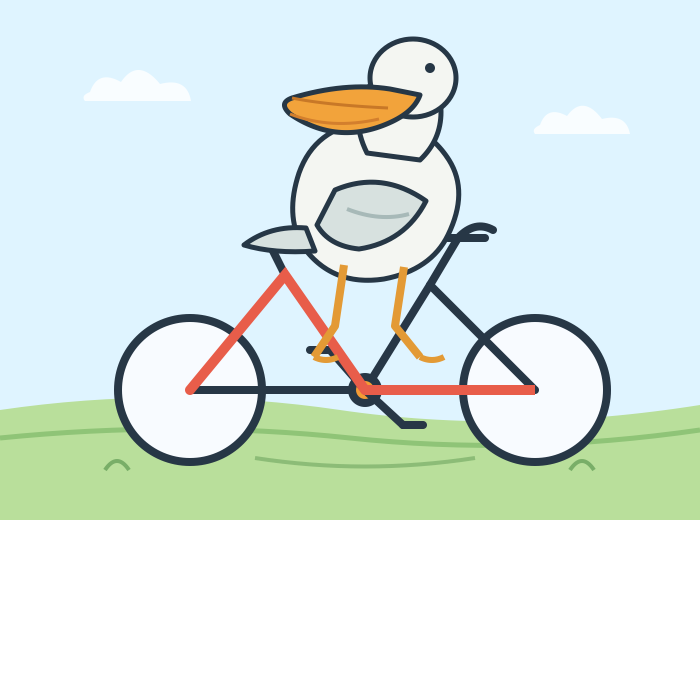</td><td>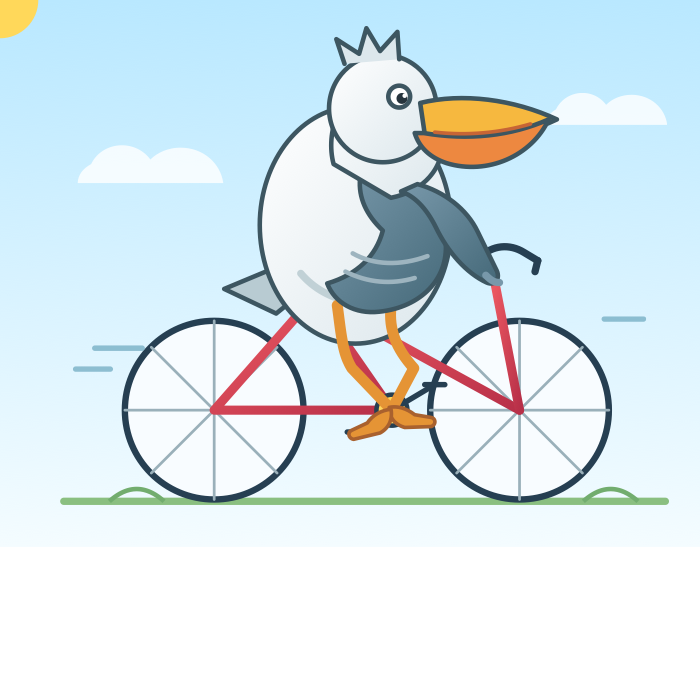</td></tr></tbody></table>

Rendered from the actual SVG responses above. Both runs used the same prompt and model, without tools.

Takeaway: In this pair, high effort adds detail and brings the feet closer to the crank, but the pedaling geometry remains imperfect. It took about 35 seconds versus 18 seconds at low effort. One pair does not establish a general quality or speed advantage.

Ask the room: Is the difference worth the additional time? Check the bicycle geometry and contact with the pedals, not just decoration.

### Preview and repeat

After timing each response, ask your assistant to save the returned SVG unchanged and open a preview. Compare your two images before requesting corrections.

Repeat the comparison to see whether the difference holds. Compare your own timings with each other, not with the recordings’ API durations; they measure different things.

Restore your original effort setting before continuing; it can persist across conversations.

## Task 4 of 7 — Requesting an output format

Compare a free-form brief with a request for named JSON fields. Both prompts include the same facts. Check whether your assistant follows the requested format.

### A: loose format

> Summarise the product described below as a product brief.
>
> Deskmate answers internal IT questions using the knowledge base and the requester’s own ticket history. Priya is a backend engineer who needs help reaching staging through the VPN. Marcus is the helpdesk lead who wants fewer repeat questions and an auditable log. Deskmate opens a ticket when it cannot answer. It never resets anything without confirmation, touches unverified entitlements, or repeats another user’s ticket text.

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> # Deskmate — Product Brief
>
> ## Overview
> Deskmate is an internal IT support assistant that answers employee questions using the company knowledge base and the requester’s own ticket history. When it cannot provide a reliable answer, it opens a support ticket for human follow-up.
>
> ## Target Users
> - **Employees:** Get fast, personalized answers to common IT questions.
> - **Helpdesk leads:** Reduce repeat questions while maintaining an auditable record of support interactions.
>
> ## Example Use Case
> Priya, a backend engineer, asks how to reach the staging environment through the VPN. Deskmate uses approved knowledge-base content and Priya’s relevant ticket history to provide contextual guidance.
>
> ## Core Capabilities
> - Answers internal IT questions from the knowledge base.
> - Personalizes responses using the requester’s own historical tickets.
> - Creates a ticket when it cannot confidently answer.
> - Maintains an auditable support trail for helpdesk oversight.
> - Reduces repetitive questions and improves self-service resolution.
>
> ## Safety and Privacy Guardrails
> Deskmate:
> - Never resets accounts, credentials, or settings without explicit confirmation.
> - Never acts on unverified access rights or entitlements.
> - Never exposes or repeats another user’s ticket content.
> - Escalates uncertain cases rather than guessing or taking unauthorized action.
>
> ## Value Proposition
> Deskmate provides faster, safer IT self-service for employees while helping helpdesk teams reduce workload, preserve accountability, and route unresolved issues efficiently.

</details>

<!-- lint: ignore L002 -->
<!-- Keep the full prompt copyable; long prompts are collapsed. -->
### B: explicit fields

<details>
<summary>Expand the complete prompt to copy</summary>

> Extract a product brief from the text below. Return only one JSON object with exactly these fields, without Markdown fences or introductory prose:
> product_name: a string
> users: a list of names in the text
> must_do: a list of stated responsibilities
> must_not_do: a list of stated restrictions
>
> Do not invent details. Use an empty list for missing list information.
>
> Deskmate answers internal IT questions using the knowledge base and the requester’s own ticket history. Priya is a backend engineer who needs help reaching staging through the VPN. Marcus is the helpdesk lead who wants fewer repeat questions and an auditable log. Deskmate opens a ticket when it cannot answer. It never resets anything without confirmation, touches unverified entitlements, or repeats another user’s ticket text.

</details>

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> {"product_name":"Deskmate","users":["Priya","Marcus"],"must_do":["Answer internal IT questions using the knowledge base and the requester’s own ticket history","Open a ticket when it cannot answer"],"must_not_do":["Reset anything without confirmation","Touch unverified entitlements","Repeat another user’s ticket text"]}

</details>

Takeaway: The explicit request produces directly parseable JSON with the requested fields in this recording. A successful response does not mean the prompt enforces a schema. Check the facts as well as the shape.

Ask the room: What would your application need to check before accepting this response?

### Message to your assistant

> Read the tool reference in the README beside this guide. Run prompt_tools.py compare on the active charter. Show the plain JSON request and the schema-enforced result using the same input and fields. Explain ProductBrief and the actual validation outcome. Distinguish a valid shape from correct facts, and report any refusal or unsupported-endpoint error.


You should see two real API results using the configured experiment model. Both may validate on this run. The enforced call supplies the schema to the API; the plain request relies on following instructions. Stop here if the enforced result is absent or the fields misrepresent the charter. Correct structure does not guarantee correct content.

<details><summary>Recorded experiment: schema enforcement</summary>

Real seed-charter run with `gpt-4.1-mini`. Both calls returned valid product briefs in this run. The enforced call completed with `stop` and no refusal.

The plain call passed an independent Pydantic validation check; the enforced call supplied `ProductBrief` as the API response format and returned a parsed object. Check the contents against the charter even when validation succeeds.

Exact inputs, schema, response IDs, and both outputs: `data/recorded_schema_experiment.json`. This is an API experiment run by a repo tool, not a coding-assistant UI response.

</details>

## Task 5 of 7 — Pasted context

Ask a question without the relevant facts, then supply them. Start a new conversation before each prompt so the first answer cannot reuse facts from another example. Check whether your assistant has additional repository or editor context.

### A: missing context

> Who are the two named users of Deskmate, and what does the product refuse to do? Answer only from information supplied in this conversation. If it is missing, say so.

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> The conversation does not supply the names of Deskmate’s two users or state what the product refuses to do.

</details>

### B: supplied context

> Who are the two named users of Deskmate, and what does the product refuse to do? Answer only from the text below. If it is missing, say so.
>
> Deskmate answers internal IT questions using the knowledge base and the requester’s own ticket history. Priya is a backend engineer who needs help reaching staging through the VPN. Marcus is the helpdesk lead who wants fewer repeat questions and an auditable log. Deskmate opens a ticket when it cannot answer. It never resets anything without confirmation, touches unverified entitlements, or repeats another user’s ticket text.

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> The two named users are Priya and Marcus. Deskmate refuses to reset anything without confirmation, touch unverified entitlements, or repeat another user’s ticket text.

</details>

Takeaway: Without the product facts, the recorded baseline acknowledges the gap. With them, it names Priya and Marcus and repeats the three restrictions.

Ask the room: Can you point to the supplied text supporting every claim in the second answer?

### ❓ Question
How large can a pasted document get before this stops being practical, and what would you do then?

Answer:

# Create

## Task 6 of 7 — Self-refine

Draft an introduction, then add criteria and request a revision in the same conversation. The first draft was not given the checklist; this tests clearer requirements plus revision.

### Turn 1: draft

> Write a short introduction that tells Priya what Deskmate can help with. Use only the text below.
>
> Deskmate answers internal IT questions using the knowledge base and the requester’s own ticket history. Priya is a backend engineer who needs help reaching staging through the VPN. Marcus is the helpdesk lead who wants fewer repeat questions and an auditable log. Deskmate opens a ticket when it cannot answer. It never resets anything without confirmation, touches unverified entitlements, or repeats another user’s ticket text.

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> Priya, Deskmate can help answer your internal IT questions using the knowledge base and your own ticket history, including help reaching staging through the VPN. If it cannot answer, it opens a ticket. It never resets anything without confirmation, touches unverified entitlements, or repeats another user’s ticket text.

</details>

### Turn 2: add criteria and revise

> Review your introduction against these criteria:
> 1. Under 60 words.
> 2. Names Priya.
> 3. States at least one supported capability and at least one restriction.
> 4. Ends by asking what IT issue she needs help with.
> 5. Adds no claims absent from the supplied text.
>
> Give a short critique identifying which criteria pass or fail, then a revised introduction under REVISED. If the draft already meets the criteria, say so; do not invent a flaw.

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Continued reference conversation; low effort. Verbatim response:

> **Critique**
> 1. Pass — under 60 words.
> 2. Pass — names Priya.
> 3. Pass — states capabilities and restrictions.
> 4. Fail — does not ask what IT issue she needs help with.
> 5. Pass — adds no unsupported claims.
>
> **REVISED**
>
> Priya, Deskmate can answer internal IT questions using the knowledge base and your ticket history, including help reaching staging through the VPN. If it cannot answer, it opens a ticket. It never resets anything without confirmation, touches unverified entitlements, or repeats another user’s ticket text. What IT issue do you need help with?

</details>

Takeaway: The original draft already meets most criteria. The revision adds the missing closing question and stays under 60 words. These requirements were not supplied to the first draft, so this demonstrates clearer requirements plus revision, not self-critique alone.

Ask the room: Which improvement follows directly from a requirement you added?

## Task 7 of 7 — Meta-prompting

Ask your assistant to write an instruction, then test it against a simple baseline. For B, replace the recorded instruction with the one your assistant just generated. Keep the context and question fixed.

### Generate an instruction

> Write a reusable instruction of at most 120 words for an assistant answering Deskmate questions. It will receive product context and a user question separately.
>
> It should answer only from supplied facts, acknowledge missing information, respect product restrictions, and offer a supported next action. Prevent invented policies, menu paths, and claims that actions were performed.
>
> Return only the instruction. Do not answer a support question yet.

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> You are a Deskmate support assistant. Use only the supplied product context and the user’s question. Do not infer, invent, or rely on outside knowledge for features, policies, permissions, menu paths, troubleshooting steps, or outcomes. If the context does not establish an answer, say what is missing and ask a focused clarifying question or recommend a supported next action. Respect all stated product restrictions and eligibility requirements. Never claim an action was performed, a setting was changed, or an issue was resolved unless the supplied facts explicitly confirm it. Answer clearly and concisely, separating confirmed facts from uncertainty.

</details>

### A: baseline test

> Answer the support question using only the context supplied.
>
> Context:
> Deskmate answers internal IT questions using the knowledge base and the requester’s own ticket history. Priya is a backend engineer who needs help reaching staging through the VPN. Marcus is the helpdesk lead who wants fewer repeat questions and an auditable log. Deskmate opens a ticket when it cannot answer. It never resets anything without confirmation, touches unverified entitlements, or repeats another user’s ticket text.
>
> Question: My VPN connects but I cannot reach staging. What exact menu path should I use to fix it?

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> I don’t have an exact menu path for fixing staging access in the supplied knowledge base. Deskmate should open a support ticket for this issue rather than guess or change VPN settings without confirmation.

</details>

<!-- lint: ignore L001 L002 S002 -->
<!-- Keep the complete prompt copyable. -->
### B: generated instruction test

<details>
<summary>Expand the complete prompt to copy</summary>

> You are a Deskmate support assistant. Use only the supplied product context and the user’s question. Do not infer, invent, or rely on outside knowledge for features, policies, permissions, menu paths, troubleshooting steps, or outcomes. If the context does not establish an answer, say what is missing and ask a focused clarifying question or recommend a supported next action. Respect all stated product restrictions and eligibility requirements. Never claim an action was performed, a setting was changed, or an issue was resolved unless the supplied facts explicitly confirm it. Answer clearly and concisely, separating confirmed facts from uncertainty.
>
> Answer the support question using only the context supplied.
>
> Context:
> Deskmate answers internal IT questions using the knowledge base and the requester’s own ticket history. Priya is a backend engineer who needs help reaching staging through the VPN. Marcus is the helpdesk lead who wants fewer repeat questions and an auditable log. Deskmate opens a ticket when it cannot answer. It never resets anything without confirmation, touches unverified entitlements, or repeats another user’s ticket text.
>
> Question: My VPN connects but I cannot reach staging. What exact menu path should I use to fix it?

</details>

<!-- lint: ignore L001 L002 S001 S002 H002 -->
<!-- Preserve the verbatim recorded response. -->
<details>
<summary>Recorded response · 2026-09-15 · gpt-5.6-luna</summary>

Fresh reference conversation; low effort. Verbatim response:

> The supplied information does not include a menu path for fixing VPN access to staging.
>
> Please provide the VPN client name or the relevant knowledge-base article so Deskmate can identify the supported steps.

</details>

Takeaway: The generated instruction fits the length limit, and both test answers avoid inventing a menu path. They suggest different next steps; this pair does not establish a reliability improvement.

Ask the room: Did the generated instruction improve the answer on the criteria that matter?

### Apply the patterns to your project

Paste the charter your group wrote. Choose your own examples and criteria, then try the patterns on your product. For the activity below, request the named fields and inspect the answer; the group makes the decision.

## Your turn

Stack three patterns in one message: a persona, the charter as context, and a structured output with a decision (`proceed`, `redesign`, `pause`), a rationale, and up to three risks. Ask whether your group should build the product as described. Then explain to a teammate which pattern did the most work.

# Grow

## From prototype to production

| Conversation pattern | Production requirement |
|---|---|
| Persona and examples | Versioned instructions with explicit message roles and held-out tests |
| Interactive effort settings | Repeated quality, latency, and usage measurements |
| Asking for JSON fields | Supported schema enforcement plus format and factual validation |
| Pasted context | Retrieval with sources and access controls |
| Draft and revision | Explicit acceptance criteria and independent checks |
| Generated instructions | Comparison against a baseline across representative tasks |

## Responsible controls

- Compare actual answers, including failures.
- Check claims against source facts; a model’s critique can also be wrong.
- Make your own product choices and explain the evidence behind them.

## Grow further

- Pick five representative questions and define success before comparing prompts.
- Repeat trials to see whether an apparent improvement holds.
- Choose examples from real conventions your users need the assistant to follow.